# Logistic Regression from Scratch with Learning Rate Schedules

This notebook implements logistic regression from scratch using NumPy.

The objectives are:
- preprocess the Telco Churn dataset;
- implement logistic regression mathematically;
- train the model using gradient descent;
- compare multiple learning rate schedules;
- evaluate classification performance.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score

## Load Preprocessed Dataset

We use the cleaned dataset obtained after the exploratory data analysis stage.

In [46]:
df = pd.read_csv("telco_churn_cleaned.csv")
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Encode Target Variable

The target variable 'Churn' is converted into binary format:
- yes - 1;
- no - 0.

In [47]:
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

## Encode Categorical Features

Categorical variables are transformed using one-hot encoding. We use 'drop_first=True' to avoid redundant dummy variables.

In [48]:
df_encoded = pd.get_dummies(df, drop_first=True)

print(df_encoded.shape)
df_encoded.head()

(7032, 31)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [49]:
X = df_encoded.drop("Churn", axis=1).values
y = df_encoded["Churn"].values

print(X.shape)
print(y.shape)

(7032, 30)
(7032,)


## Train-Test Split

The dataset is split into training and testing subsets.

Stratified sampling is used to preserve the original churn proportion.

In [50]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5625, 30)
Test shape: (1407, 30)


## Feature Scaling

Numerical stability and convergence speed are improved by standardizing features.

In [51]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## Add Bias Term

A column of ones is added to include the intercept term in the model.

In [52]:
X_train = np.hstack([np.ones((X_train.shape[0], 1)), X_train])
X_test = np.hstack([np.ones((X_test.shape[0], 1)), X_test])

print("Train with bias:", X_train.shape)
print("Test with bias:", X_test.shape)

Train with bias: (5625, 31)
Test with bias: (1407, 31)


## Mathematical Formulation of Logistic Regression

For binary classification, logistic regression models the probability of class 1 as

$$
p(y=1 \mid x)=\sigma(z)=\frac{1}{1+e^{-z}}
$$

where

$$
z=x^\top w
$$

and $w$ is the parameter vector.

The sigmoid function transforms the linear score \(z\) into a probability value in the interval $(0,1)$.

The loss function is the logistic loss (cross-entropy loss)

$$
L(w)= -\frac{1}{m}\sum_{i=1}^{m}
\left[
y_i\log(p_i)+(1-y_i)\log(1-p_i)
\right]
$$

where

$$
p_i=\sigma(x_i^\top w)
$$

The gradient of the loss function is

$$
\nabla L(w)=\frac{1}{m}X^\top(p-y)
$$

This gradient is then used in gradient descent updates

$$
w^{(k+1)}=w^{(k)}-\eta_k \nabla L(w^{(k)})
$$

where $\eta_k$ is the learning rate schedule.

The following functions implement the mathematical formulas introduced above:
- the sigmoid activation function;
- the logistic loss;
- the gradient of the loss function.

In [53]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [54]:
def logistic_loss(w, X, y):
    eps = 1e-12
    p = sigmoid(X @ w)
    p = np.clip(p, eps, 1 - eps)

    loss = -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))
    return loss

In [55]:
def logistic_grad(w, X, y):
    m = len(y)
    p = sigmoid(X @ w)
    grad = (X.T @ (p - y)) / m
    return grad

In [56]:
def predict_proba(w, X):
    return sigmoid(X @ w)


def predict(w, X, threshold=0.5):
    return (predict_proba(w, X) >= threshold).astype(int)

## Learning Rate Schedules

We compare three optimization strategies:
- constant learning rate;
- step decay;
- inverse decay.

In [57]:
def constant_lr(lr):
    return lambda k: lr

def step_decay(lr, k1):
    def schedule(k):
        return lr / (2 ** (k // k1))
    return schedule

def inverse_decay(lr, alpha):
    def schedule(k):
        return lr / (1 + alpha * k)
    return schedule

## Gradient Descent Optimization

Weights are updated iteratively using the gradient of the logistic loss.

In [58]:
def gradient_descent_logistic(X, y, w0, lr_schedule, iterations=300):
    w = w0.copy()
    loss_history = [logistic_loss(w, X, y)]

    for k in range(iterations):
        lr = lr_schedule(k)
        grad = logistic_grad(w, X, y)
        w = w - lr * grad
        loss_history.append(logistic_loss(w, X, y))
    return w, loss_history

## Experimental Setup

We run multiple experiments to compare the effect of different learning rate schedules on convergence and predictive performance.

In [59]:
def run_logistic_experiment(X_train, y_train, X_test, y_test,
                            iterations=300, lr0=0.1, k1=20, alpha=0.01):
    n_features = X_train.shape[1]
    w0 = np.zeros(n_features)

    lr_const = constant_lr(lr0)
    lr_step = step_decay(lr0, k1=k1)
    lr_inv = inverse_decay(lr0, alpha=alpha)

    w_const, loss_const = gradient_descent_logistic(
        X_train, y_train, w0, lr_const, iterations=iterations
    )
    w_step, loss_step = gradient_descent_logistic(
        X_train, y_train, w0, lr_step, iterations=iterations
    )
    w_inv, loss_inv = gradient_descent_logistic(
        X_train, y_train, w0, lr_inv, iterations=iterations
    )

    pred_const = predict(w_const, X_test)
    pred_step = predict(w_step, X_test)
    pred_inv = predict(w_inv, X_test)

    acc_const = accuracy_score(y_test, pred_const)
    acc_step = accuracy_score(y_test, pred_step)
    acc_inv = accuracy_score(y_test, pred_inv)

    recall_const = recall_score(y_test, pred_const)
    recall_step = recall_score(y_test, pred_step)
    recall_inv = recall_score(y_test, pred_inv)

    return {
        "loss_const": loss_const,
        "loss_step": loss_step,
        "loss_inv": loss_inv,
        "acc_const": acc_const,
        "acc_step": acc_step,
        "acc_inv": acc_inv,
        "recall_const": recall_const,
        "recall_step": recall_step,
        "recall_inv": recall_inv,
        "w_const": w_const,
        "w_step": w_step,
        "w_inv": w_inv
    }


In [60]:
results = run_logistic_experiment(
    X_train,
    y_train,
    X_test,
    y_test,
    iterations=300,
    lr0=0.1,
    k1=20,
    alpha=0.01
)

## Training Loss Comparison

The following plot shows how the logistic loss changes during training for each learning rate schedule.

This helps compare the speed and stability of convergence.

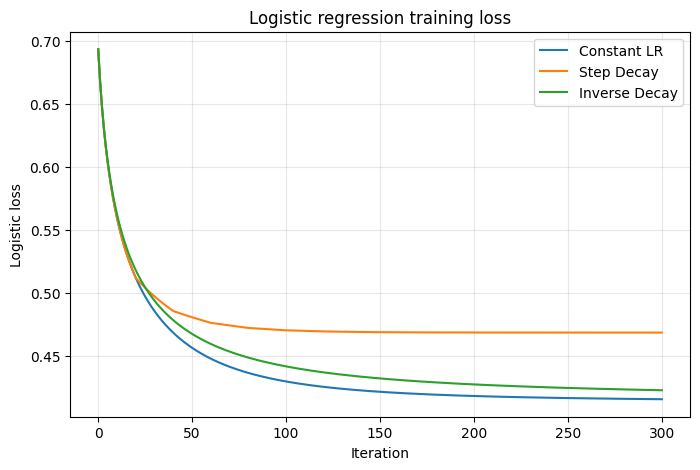

In [61]:
plt.figure(figsize=(8, 5))
plt.plot(results["loss_const"], label="Constant LR")
plt.plot(results["loss_step"], label="Step Decay")
plt.plot(results["loss_inv"], label="Inverse Decay")
plt.xlabel("Iteration")
plt.ylabel("Logistic loss")
plt.title("Logistic regression training loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Training Loss in Log Scale

The same loss curves are shown on a logarithmic scale to better visualize smaller differences between optimization strategies.

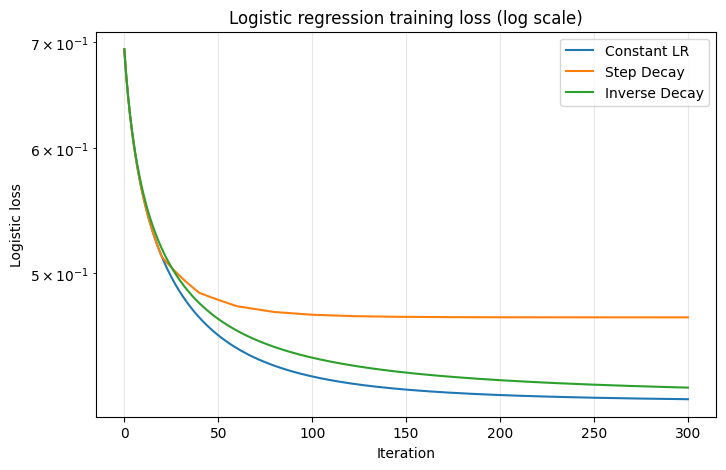

In [62]:
plt.figure(figsize=(8, 5))

plt.plot(results["loss_const"], label="Constant LR")
plt.plot(results["loss_step"], label="Step Decay")
plt.plot(results["loss_inv"], label="Inverse Decay")

plt.xlabel("Iteration")
plt.ylabel("Logistic loss")
plt.title("Logistic regression training loss (log scale)")
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Convergence Analysis

From the loss curves, we observe that:
- **constant learning rate** achieves the fastest convergence and the lowest final loss;
- **inverse decay** converges more smoothly than step decay;
- **step decay** stabilizes earlier and reaches a higher loss value.

These results suggest that, for this dataset, a constant learning rate performs best among the tested schedules.

## Final Performance Comparison

After training the model with different learning rate schedules, we compare their final performance using:

- final training loss;
- test accuracy;
- recall score.

This allows us to evaluate both convergence quality and predictive performance.

In [63]:
summary = {
    "Method": ["Constant LR", "Step Decay", "Inverse Decay"],
    "Final Loss": [
        results["loss_const"][-1],
        results["loss_step"][-1],
        results["loss_inv"][-1]
    ],
    "Test Accuracy": [
        results["acc_const"],
        results["acc_step"],
        results["acc_inv"]
    ],
    "Recall": [
        results["recall_const"],
        results["recall_step"],
        results["recall_inv"]
    ]
}

## Summary Table

The following summary presents the final results for each optimization strategy.

In [64]:
summary_df = pd.DataFrame(summary)
summary_df

,Method,Final Loss,Test Accuracy,Recall
0,Constant LR,0.415969,0.798863,0.566845
1,Step Decay,0.468739,0.777541,0.689840
2,Inverse Decay,0.423077,0.798152,0.588235


## Results Interpretation

The comparison reveals an important trade-off between optimization methods:

- **constant learning rate** achieves the lowest final loss and the highest accuracy;
- **step decay** provides the highest recall;
- **inverse decay** offers balanced performance close to constant learning rate.

For churn prediction, recall is especially important because failing to identify a customer likely to leave may result in direct business loss.

## Final Conclusion

For this customer churn prediction task, the **step decay** schedule is selected as the preferred optimization strategy.

Although its overall accuracy is slightly lower than the constant learning rate schedule, it achieves the **highest recall**, which is more important for detecting customers at risk of churning.

This highlights the importance of choosing optimization methods based not only on loss minimization, but also on task-specific business objectives.